In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


In [ ]:
df = pd.read_csv("/content/UCI_Credit_Card (1).csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
print(df.shape)

(30000, 25)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
print(df.isnull().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


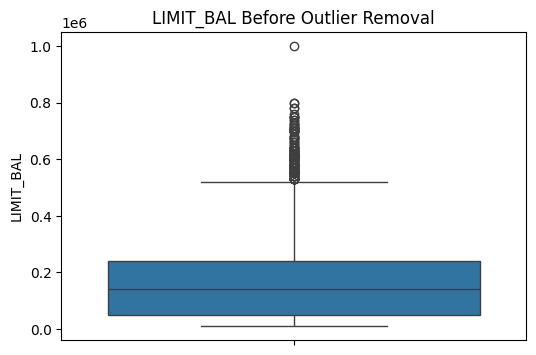

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['LIMIT_BAL'])
plt.title("LIMIT_BAL Before Outlier Removal")
plt.show()


In [ ]:
def remove_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    print("Original Shape:", df.shape)
    print("New Shape:", df_clean.shape)

    return df_clean


In [ ]:
df = remove_outliers_iqr(df, 'LIMIT_BAL')

Lower Bound: -235000.0
Upper Bound: 525000.0
Original Shape: (30000, 25)
New Shape: (29833, 25)


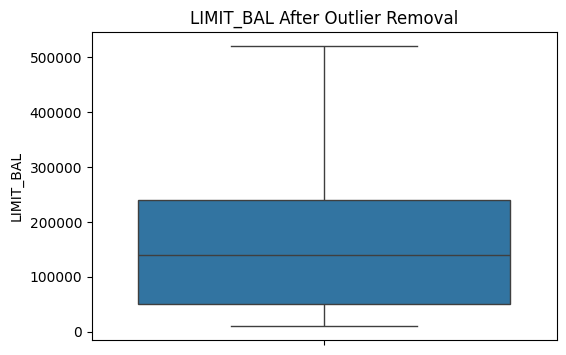

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['LIMIT_BAL'])
plt.title("LIMIT_BAL After Outlier Removal")
plt.show()

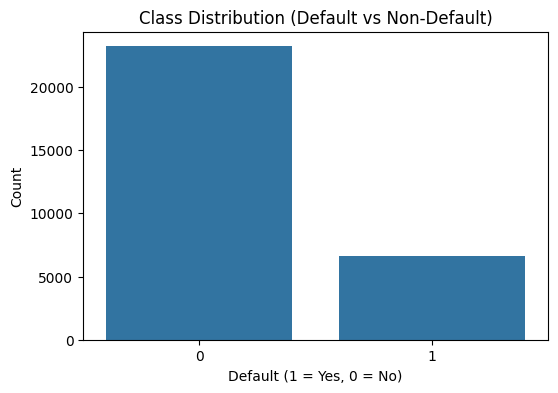

default.payment.next.month
0    0.778199
1    0.221801
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='default.payment.next.month', data=df)
plt.title("Class Distribution (Default vs Non-Default)")
plt.xlabel("Default (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()
print(df['default.payment.next.month'].value_counts(normalize=True))

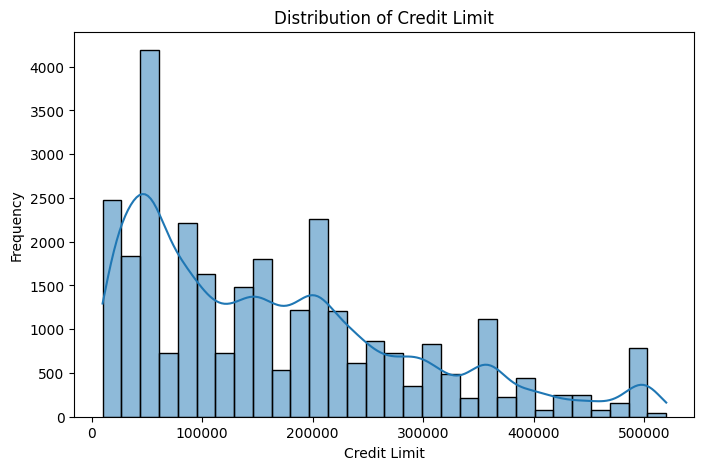

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['LIMIT_BAL'], bins=30, kde=True)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

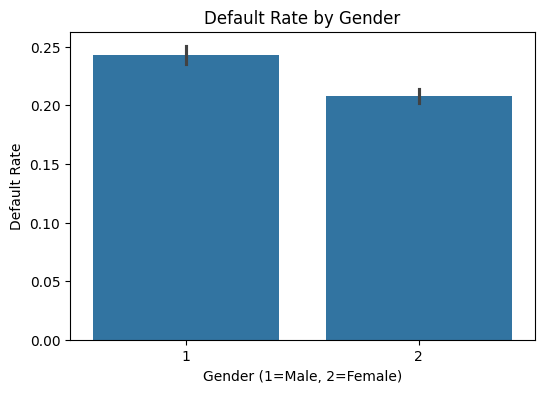

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='SEX', y='default.payment.next.month', data=df)
plt.title("Default Rate by Gender")
plt.xlabel("Gender (1=Male, 2=Female)")
plt.ylabel("Default Rate")
plt.show()

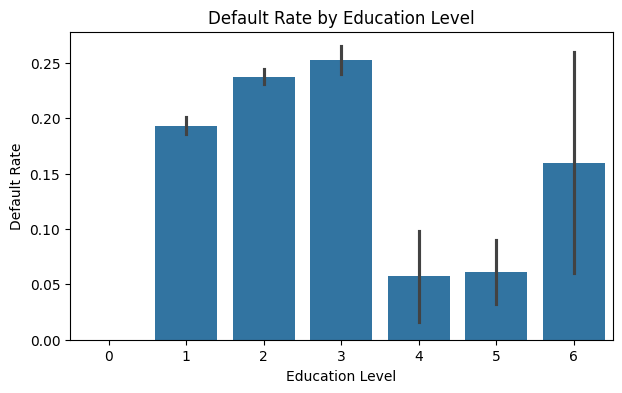

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='EDUCATION', y='default.payment.next.month', data=df)
plt.title("Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Default Rate")
plt.show()

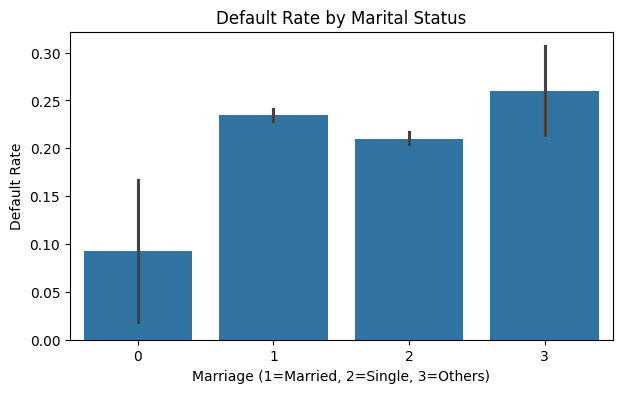

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='MARRIAGE', y='default.payment.next.month', data=df)
plt.title("Default Rate by Marital Status")
plt.xlabel("Marriage (1=Married, 2=Single, 3=Others)")
plt.ylabel("Default Rate")
plt.show()

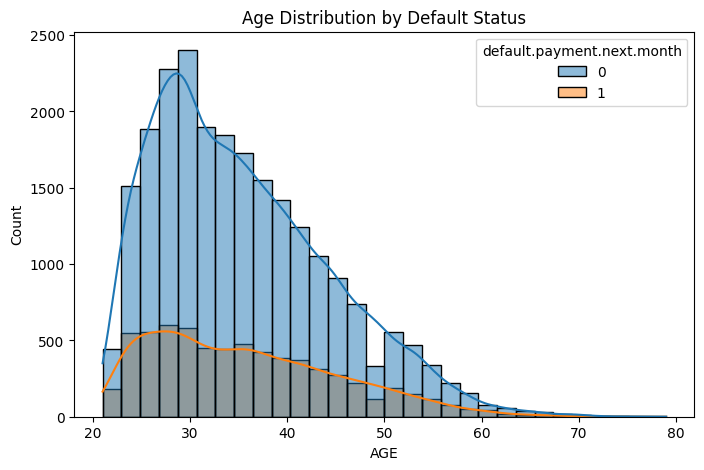

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='AGE', hue='default.payment.next.month', bins=30, kde=True)
plt.title("Age Distribution by Default Status")
plt.show()

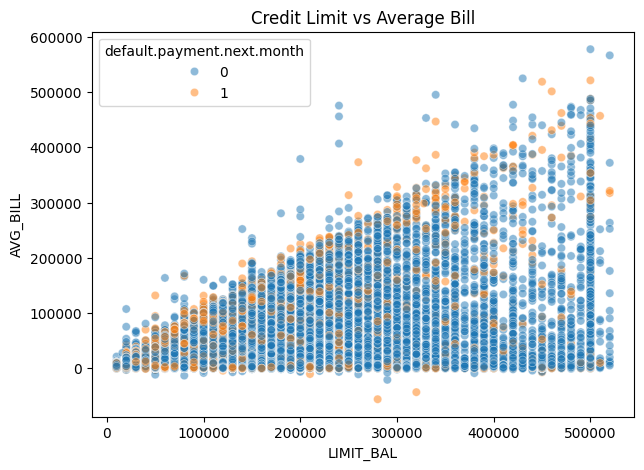

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='LIMIT_BAL', y='AVG_BILL',
                hue='default.payment.next.month',
                data=df, alpha=0.5)
plt.title("Credit Limit vs Average Bill")
plt.show()


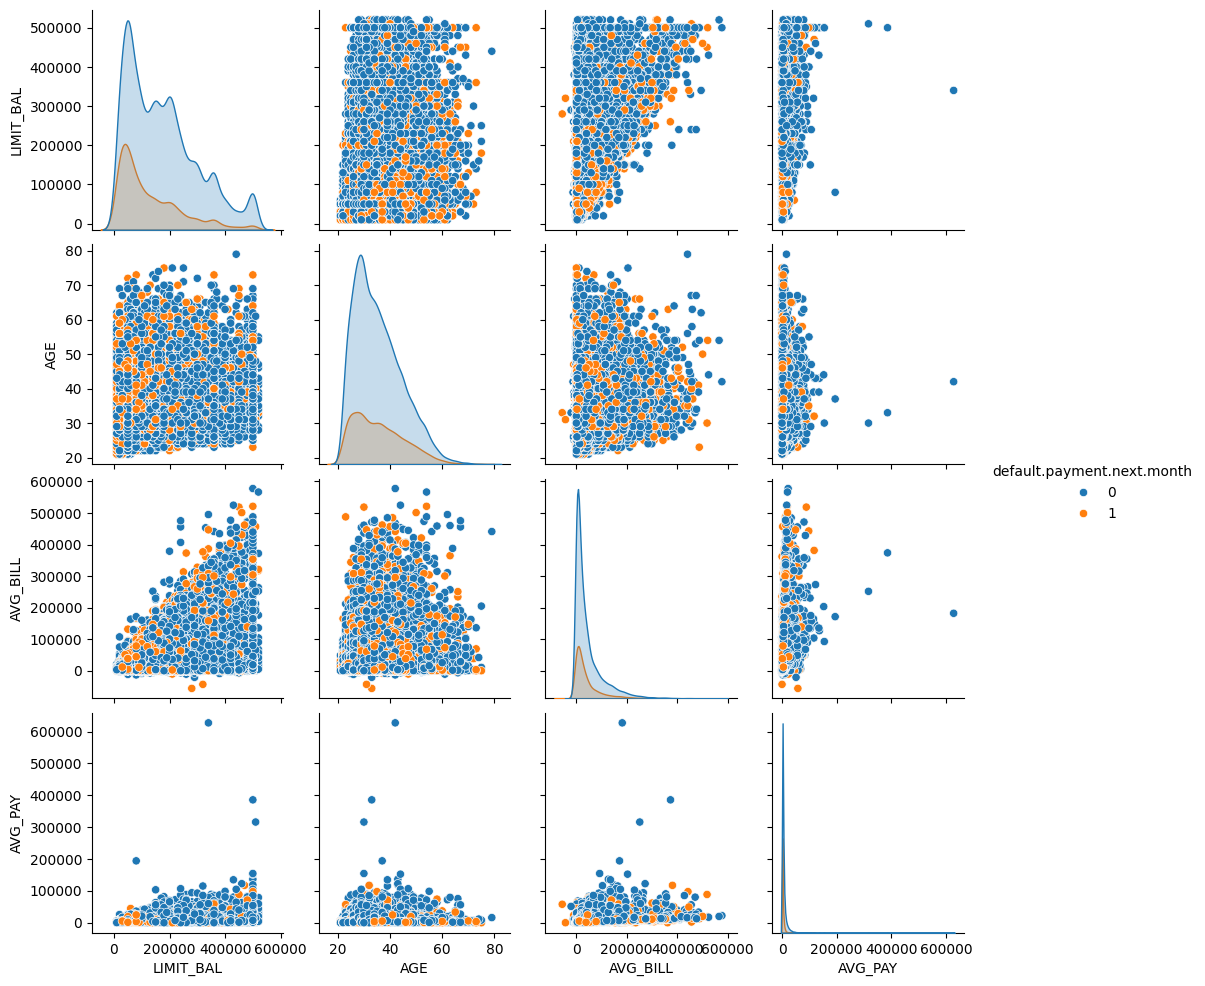

In [ ]:
selected_cols = ['LIMIT_BAL','AGE','AVG_BILL','AVG_PAY','default.payment.next.month']

sns.pairplot(df[selected_cols], hue='default.payment.next.month')
plt.show()


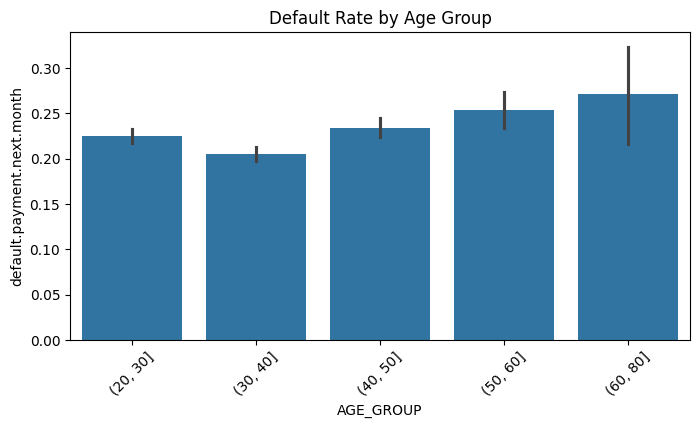

In [ ]:
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20,30,40,50,60,80])

plt.figure(figsize=(8,4))
sns.barplot(x='AGE_GROUP', y='default.payment.next.month', data=df)
plt.title("Default Rate by Age Group")
plt.xticks(rotation=45)
plt.show()

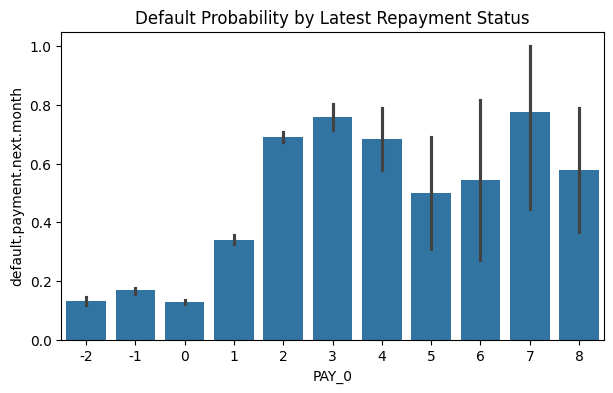

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='PAY_0', y='default.payment.next.month', data=df)
plt.title("Default Probability by Latest Repayment Status")
plt.show()

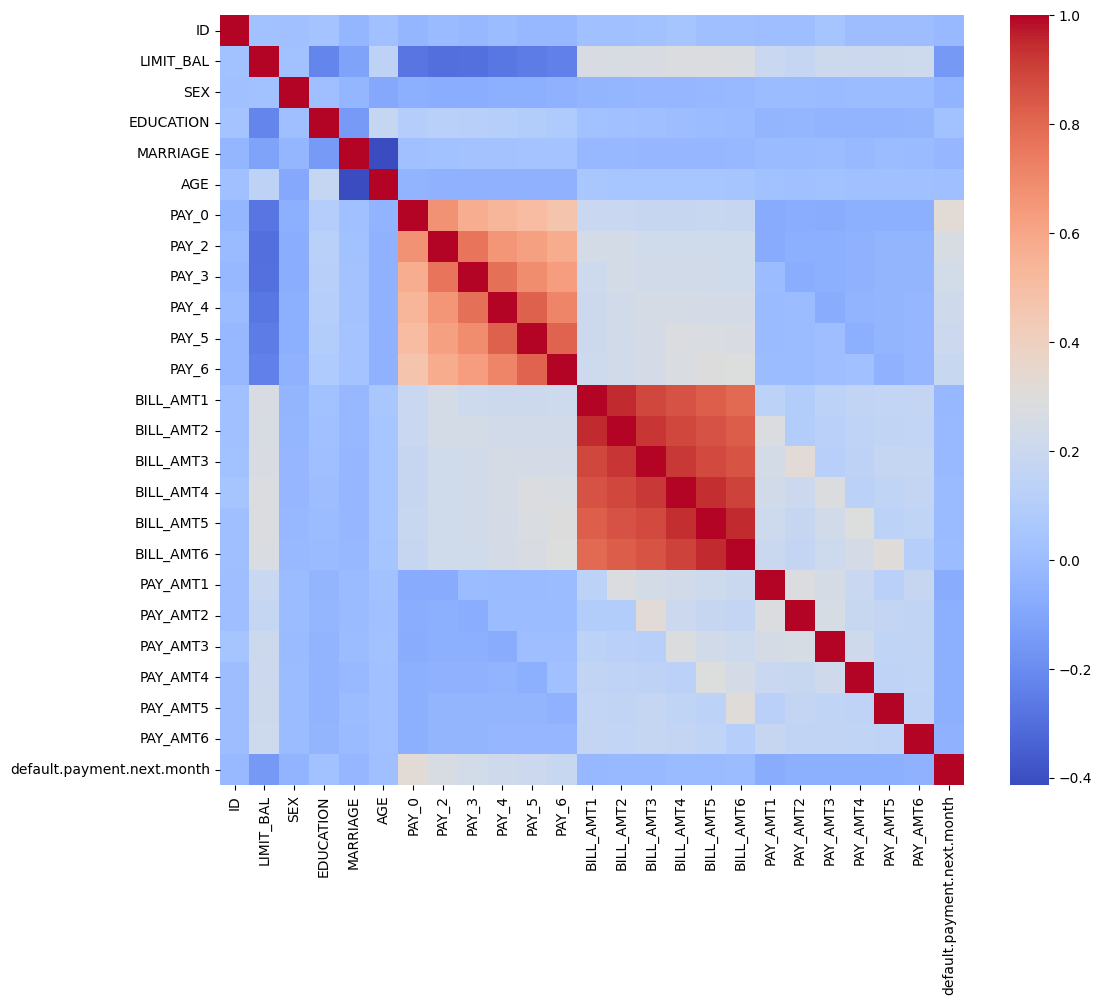

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

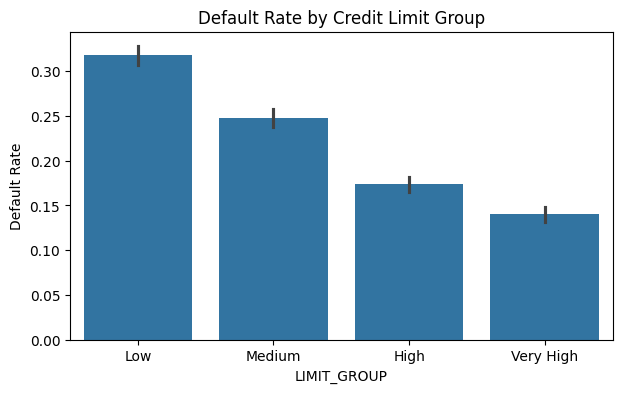

In [ ]:
# Create credit limit bins
df['LIMIT_GROUP'] = pd.qcut(df['LIMIT_BAL'], q=4, labels=['Low','Medium','High','Very High'])
plt.figure(figsize=(7,4))
sns.barplot(x='LIMIT_GROUP', y='default.payment.next.month', data=df)
plt.title("Default Rate by Credit Limit Group")
plt.ylabel("Default Rate")
plt.show()

In [ ]:
df.drop("ID", axis=1, inplace=True)

In [ ]:
X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: default.payment.next.month
0    18572
1     5294
Name: count, dtype: int64
After SMOTE: default.payment.next.month
0    18572
1    18572
Name: count, dtype: int64


Logistic Regression Results
Accuracy : 0.6777275012569131
Precision: 0.36510791366906475
Recall   : 0.6137566137566137
F1 Score : 0.45785170566676064
ROC-AUC  : 0.7085355627560622

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.70      0.77      4644
           1       0.37      0.61      0.46      1323

    accuracy                           0.68      5967
   macro avg       0.61      0.65      0.61      5967
weighted avg       0.75      0.68      0.70      5967



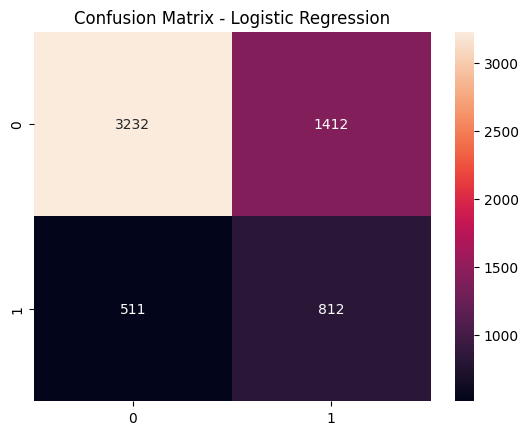

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
model = LogisticRegression(max_iter=1000)
# Train
model.fit(X_train_res, y_train_res)
# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
# Evaluation
print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

KNN Results
Accuracy : 0.6623093681917211
Precision: 0.3487762237762238
Recall   : 0.6031746031746031
F1 Score : 0.4419828302409305
ROC-AUC  : 0.6808393277877713

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.68      0.76      4644
           1       0.35      0.60      0.44      1323

    accuracy                           0.66      5967
   macro avg       0.60      0.64      0.60      5967
weighted avg       0.74      0.66      0.69      5967



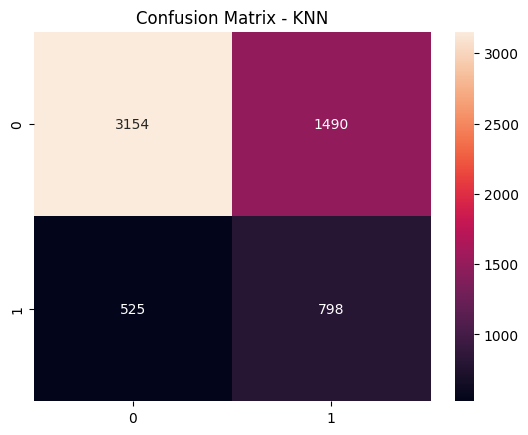

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print("KNN Results")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - KNN")
plt.show()

Decision Tree Results
Accuracy : 0.6951566951566952
Precision: 0.35096153846153844
Recall   : 0.4414210128495843
F1 Score : 0.3910277870773351
ROC-AUC  : 0.6047214751533689

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.77      0.80      4644
           1       0.35      0.44      0.39      1323

    accuracy                           0.70      5967
   macro avg       0.59      0.60      0.59      5967
weighted avg       0.72      0.70      0.71      5967



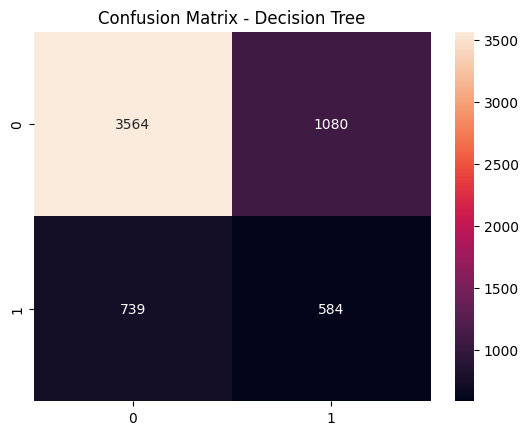

In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print("Decision Tree Results")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Random Forest Results
Accuracy : 0.7886710239651417
Precision: 0.5266323024054983
Recall   : 0.4633408919123205
F1 Score : 0.4929634097305991
ROC-AUC  : 0.746255785307711

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      4644
           1       0.53      0.46      0.49      1323

    accuracy                           0.79      5967
   macro avg       0.69      0.67      0.68      5967
weighted avg       0.78      0.79      0.78      5967



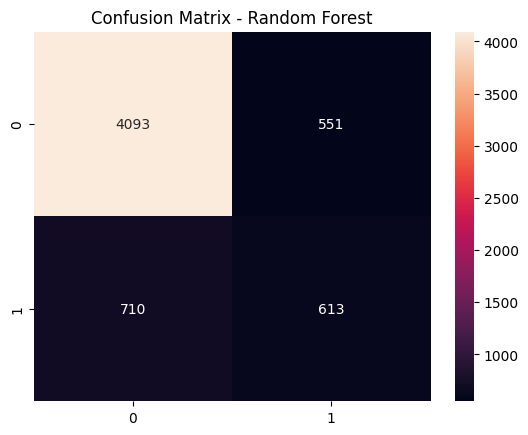

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

SVM Results
Accuracy : 0.7742584213172449
Precision: 0.49176954732510286
Recall   : 0.5419501133786848
F1 Score : 0.5156418554476807
ROC-AUC  : 0.7495373544192296

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4644
           1       0.49      0.54      0.52      1323

    accuracy                           0.77      5967
   macro avg       0.68      0.69      0.68      5967
weighted avg       0.78      0.77      0.78      5967



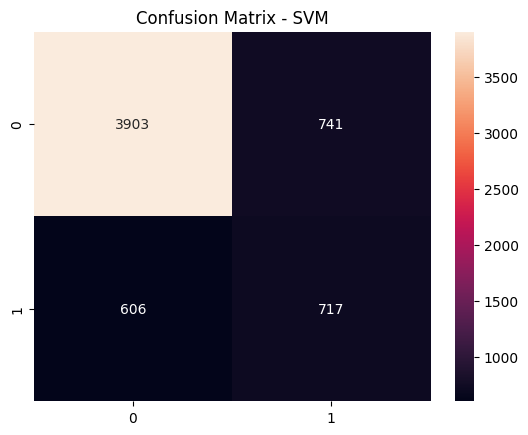

In [ ]:
# Support Vector Machine
from sklearn.svm import SVC
model = SVC(kernel='rbf', probability=True)
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print("SVM Results")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.show()

Naive Bayes Results
Accuracy : 0.45483492542316073
Precision: 0.26968973747016706
Recall   : 0.854119425547997
F1 Score : 0.4099401414837656
ROC-AUC  : 0.7288276780709413

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.34      0.49      4644
           1       0.27      0.85      0.41      1323

    accuracy                           0.45      5967
   macro avg       0.58      0.60      0.45      5967
weighted avg       0.75      0.45      0.47      5967



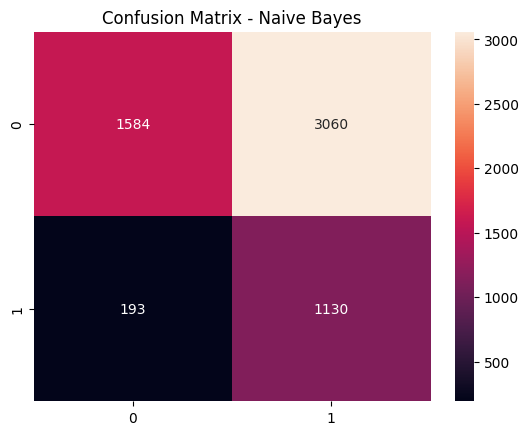

In [ ]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print("Naive Bayes Results")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [ ]:
results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"
])

results_df.sort_values(by="ROC-AUC", ascending=False)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,SVM,0.774258,0.491770,0.541950,0.515642,0.749537
3,Random Forest,0.791855,0.535187,0.465608,0.497979,0.743731
5,Naive Bayes,0.454835,0.269690,0.854119,0.409940,0.728828
0,Logistic Regression,0.677728,0.365108,0.613757,0.457852,0.708536
1,KNN,0.662309,0.348776,0.603175,0.441983,0.680839
2,Decision Tree,0.700520,0.358537,0.444444,0.396895,0.608898


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "Naive Bayes": GaussianNB()
}
roc_data = {}
for name, model in models.items():
    # Train model
    model.fit(X_train_res, y_train_res)
    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    # Calculate ROC values
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc_score)

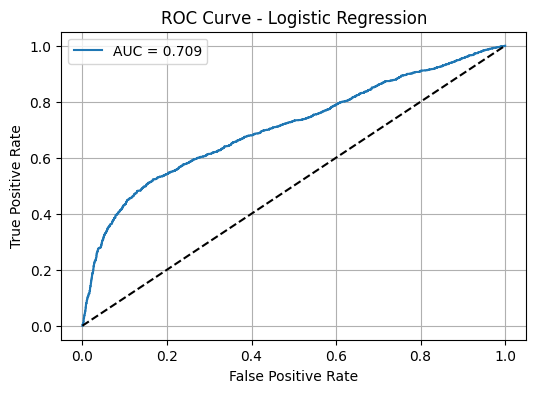

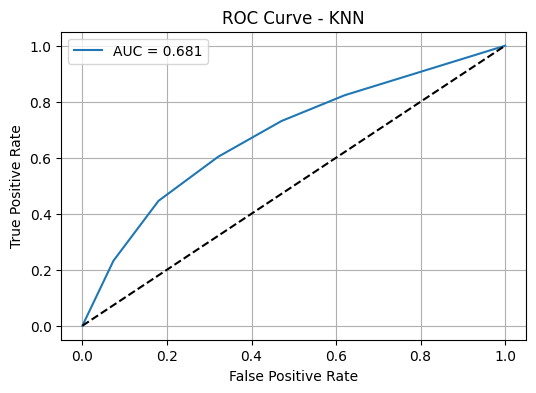

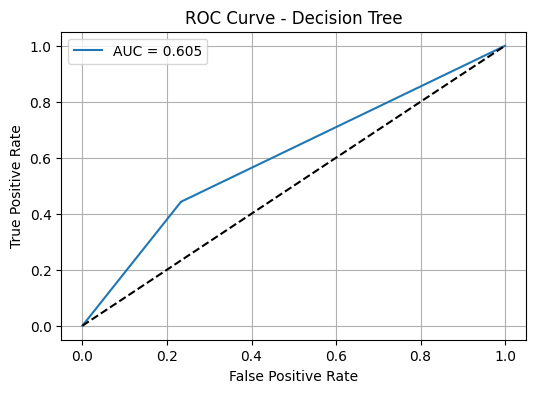

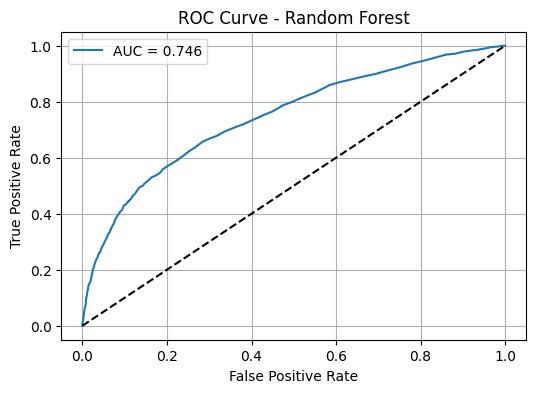

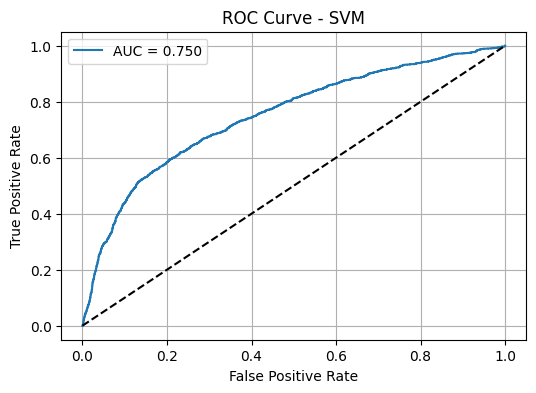

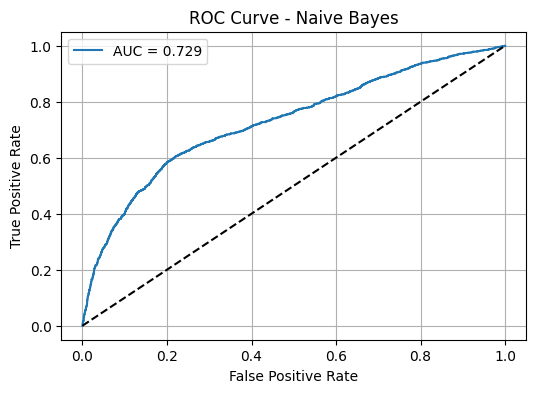

In [ ]:
for name, (fpr, tpr, auc_score) in roc_data.items():

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0,1], [0,1], 'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
log_model = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_log = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_log.fit(X_train_res, y_train_res)

print("Best Parameters:", grid_log.best_params_)
print("Best ROC-AUC:", grid_log.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best ROC-AUC: 0.7349770279135228


In [ ]:
best_log = grid_log.best_estimator_
y_pred = best_log.predict(X_test)
y_prob = best_log.predict_proba(X_test)[:,1]

print("Tuned Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_prob))

Tuned Logistic Regression ROC-AUC: 0.7085710444575954


In [ ]:
rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train_res, y_train_res)

print("Best RF Parameters:", grid_rf.best_params_)
print("Best RF ROC-AUC:", grid_rf.best_score_)


Best RF Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF ROC-AUC: 0.9336453834686609


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

print("Tuned Random Forest ROC-AUC:",
      roc_auc_score(y_test, y_prob))

Tuned Random Forest ROC-AUC: 0.7483597037245371


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

svm_model = SVC(probability=True)

param_dist = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

random_svm = RandomizedSearchCV(
    svm_model,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_svm.fit(X_train_res, y_train_res)

print("Best SVM Parameters:", random_svm.best_params_)
print("Best SVM ROC-AUC:", random_svm.best_score_)


Best SVM Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'C': 10}
Best SVM ROC-AUC: 0.7824914182429021


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "SVM"],
    "Best CV ROC-AUC": [
        grid_log.best_score_,
        grid_rf.best_score_,
        random_svm.best_score_
    ]
})

comparison
